# 01 — EDA

# 1. Data overview

In [48]:
import pandas as pd

df = pd.read_csv("data/raw/modified_GermanCredit.csv")

In [49]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [50]:
df.shape

(1000, 21)

In [51]:
df.columns

Index(['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings',
       'employment_duration', 'installment_rate', 'personal_status_sex',
       'other_debtors', 'present_residence', 'property', 'age',
       'other_installment_plans', 'housing', 'number_credits', 'job',
       'people_liable', 'telephone', 'foreign_worker', 'credit_risk'],
      dtype='object')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

# 2. Data quality check

In [53]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())
print(missing_values[missing_values > 0])

Total missing values: 0
Series([], dtype: int64)


In [54]:
df.duplicated().sum()

np.int64(0)

# 3. Feature Types

In [55]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
target_col = "credit_risk"

numerical_features = [col for col in numerical_cols if col != target_col]
categorical_features = categorical_cols

print("Numerical columns:")
print(numerical_features)
print("Number of numerical features:", len(numerical_features))

print("\nCategorical columns:")
print(categorical_features)
print("Number of categorical features:", len(categorical_features))

print("\nTarget column:")
print(target_col)

Numerical columns:
['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable']
Number of numerical features: 7

Categorical columns:
['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Number of categorical features: 13

Target column:
credit_risk


In [56]:
df[numerical_features].describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [57]:
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} categories")

status: 4 categories
credit_history: 5 categories
purpose: 10 categories
savings: 5 categories
employment_duration: 5 categories
personal_status_sex: 4 categories
other_debtors: 3 categories
property: 4 categories
other_installment_plans: 3 categories
housing: 3 categories
job: 4 categories
telephone: 2 categories
foreign_worker: 2 categories


In [58]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- status ---
status
no checking account                           394
... < 100 DM                                  274
0 <= ... < 200 DM                             269
... >= 200 DM / salary for at least 1 year     63
Name: count, dtype: int64

--- credit_history ---
credit_history
existing credits paid back duly till now       530
critical account/other credits existing        293
delay in paying off in the past                 88
all credits at this bank paid back duly         49
no credits taken/all credits paid back duly     40
Name: count, dtype: int64

--- purpose ---
purpose
domestic appliances    280
car (new)              234
radio/television       181
car (used)             103
others                  97
retraining              50
education               22
repairs                 12
furniture/equipment     12
business                 9
Name: count, dtype: int64

--- savings ---
savings
... < 100 DM                  603
unknown/no savings account    183
100 <= ... < 500 

# 4. Target distributions

In [59]:
target_counts = df["credit_risk"].value_counts()
target_percent = df["credit_risk"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent)

Target counts:
credit_risk
1    700
0    300
Name: count, dtype: int64

Target percentages:
credit_risk
1    70.0
0    30.0
Name: proportion, dtype: float64


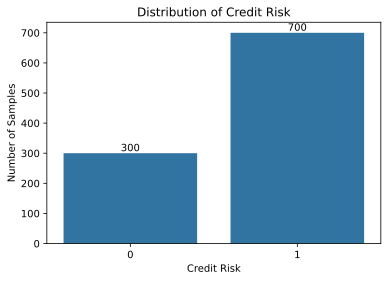

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="credit_risk"
)

plt.title("Distribution of Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Samples")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Target observations

- `credit_risk` is a binary target variable with two classes: 0 and 1.
- Class 1 contains 700 samples (70%).
- Class 0 contains 300 samples (30%).
- The target therefore shows a moderate class imbalance.
- No resampling or class balancing is performed during the EDA stage.

# 5. Numerical Feature Analysis

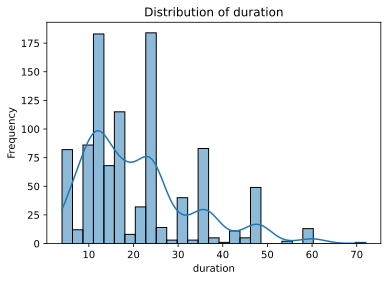

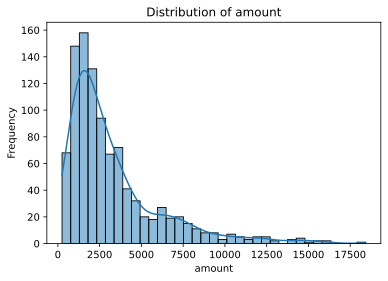

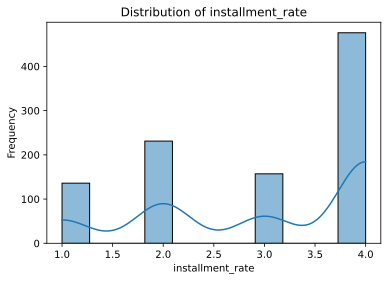

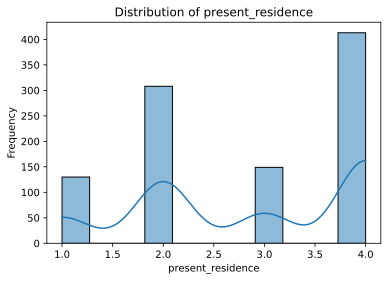

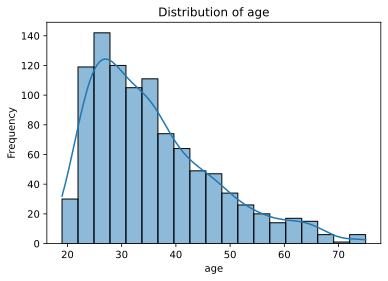

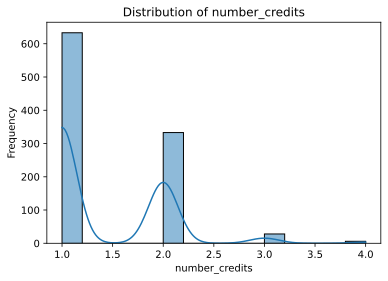

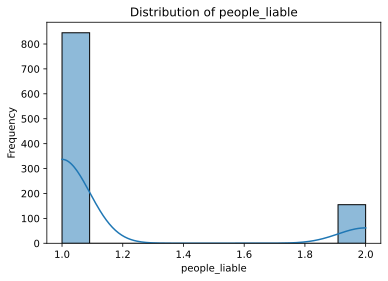

In [61]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))
    
    sns.histplot(
        data=df,
        x=col,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

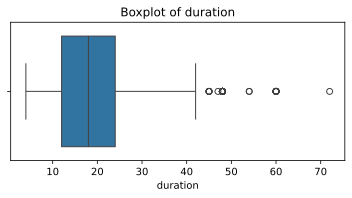

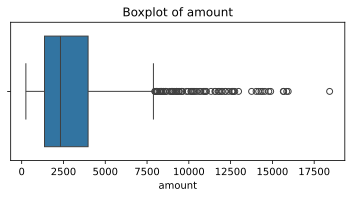

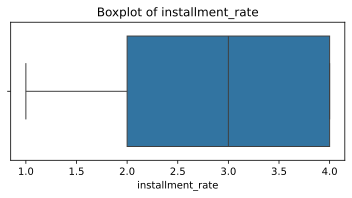

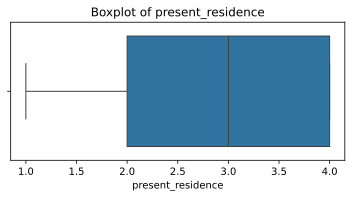

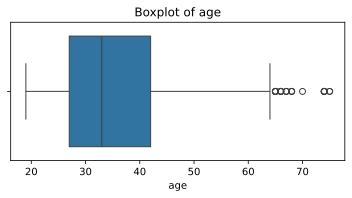

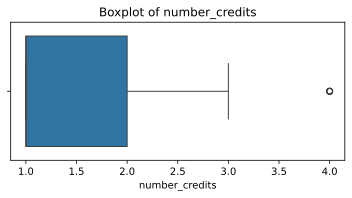

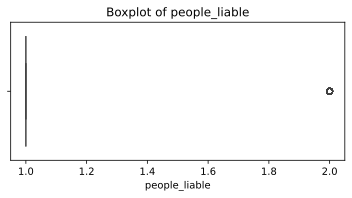

In [62]:
for col in numerical_features:
    plt.figure(figsize=(6, 2.5))
    
    sns.boxplot(
        data=df,
        x=col
    )
    
    plt.title(f"Boxplot of {col}")
    plt.show()

# 6. Categorical Feature Analysis

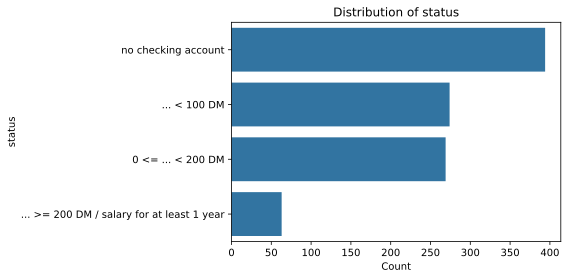

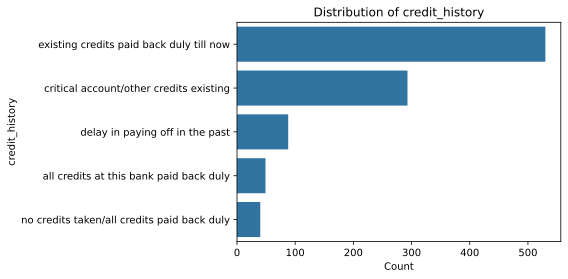

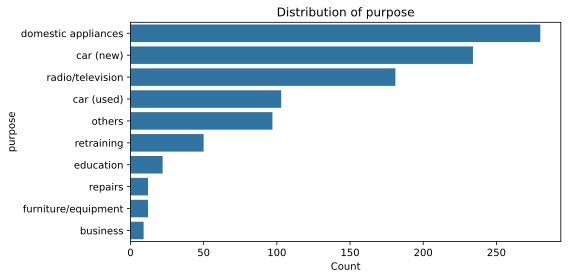

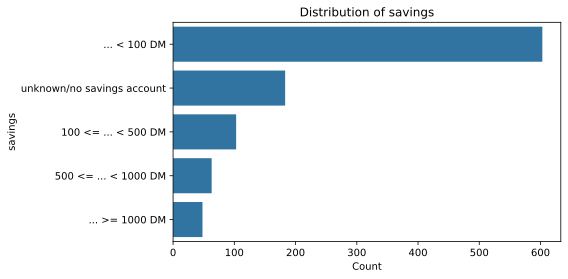

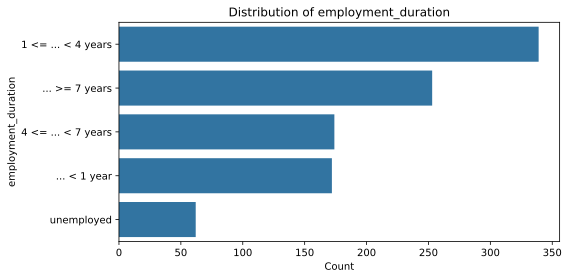

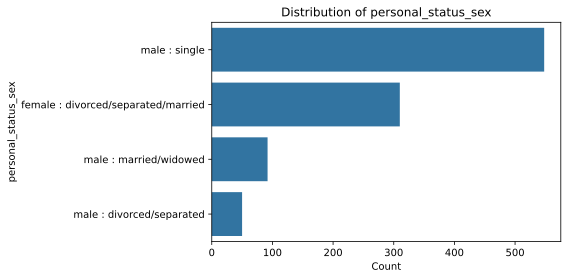

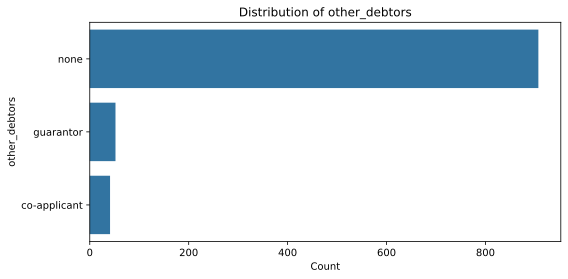

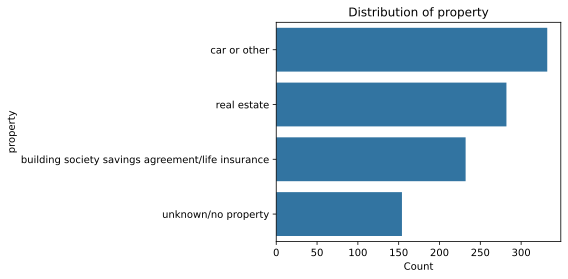

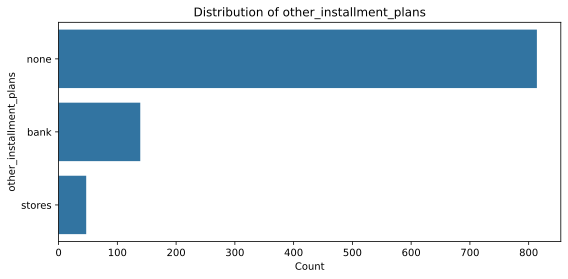

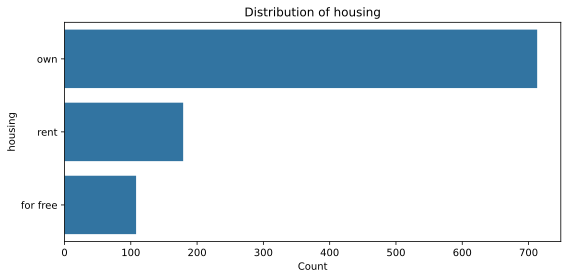

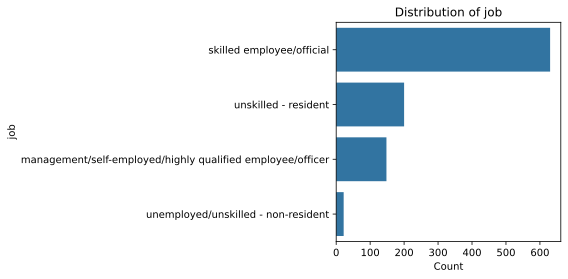

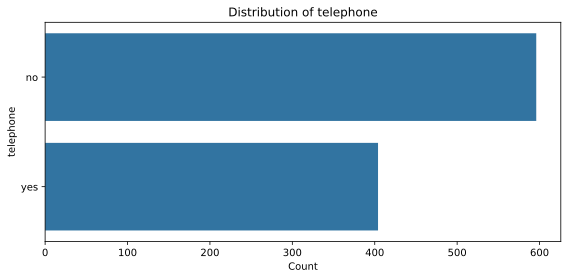

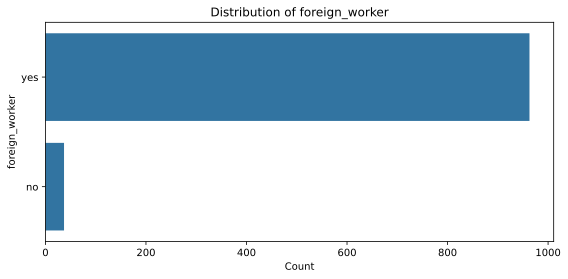

In [63]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        y=col,
        order=order
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

# 7. Feature vs Target Analysis

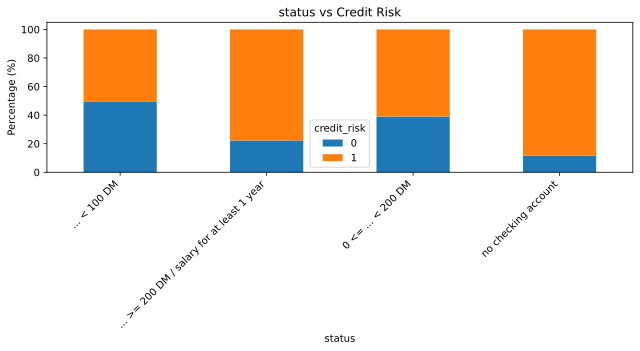

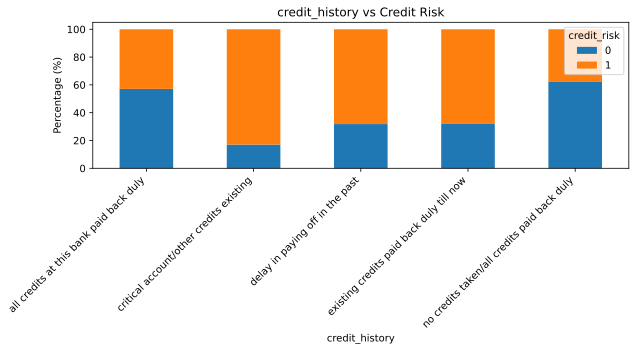

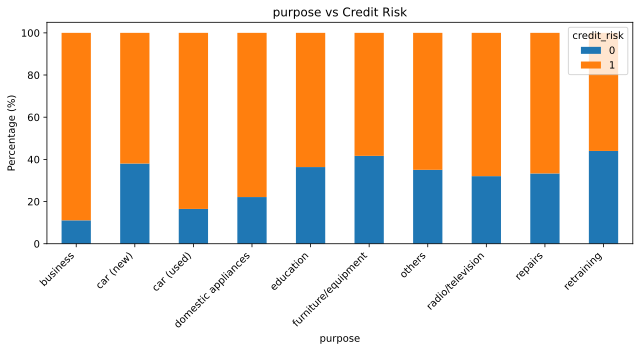

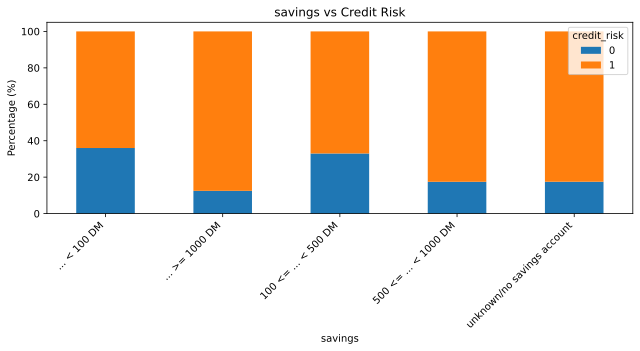

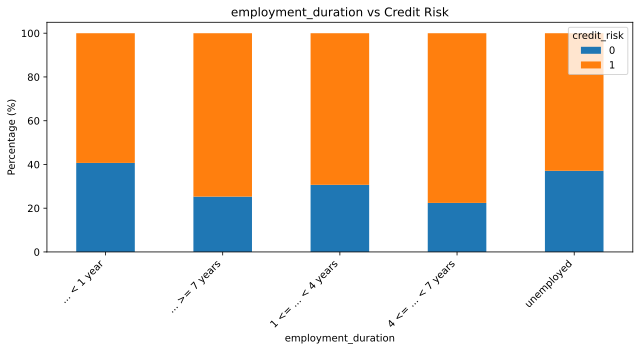

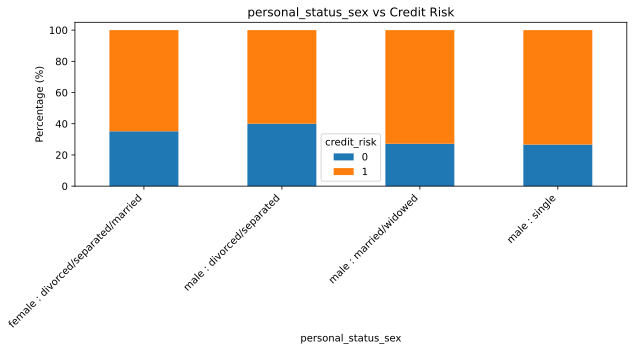

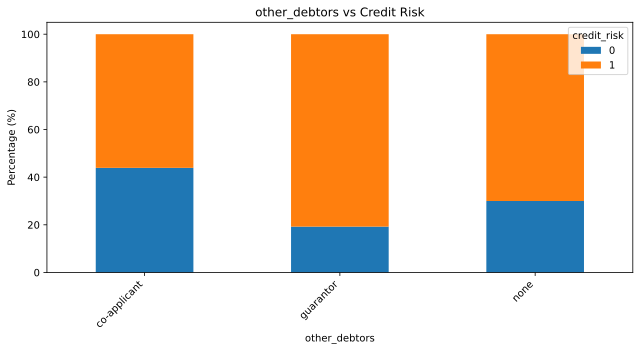

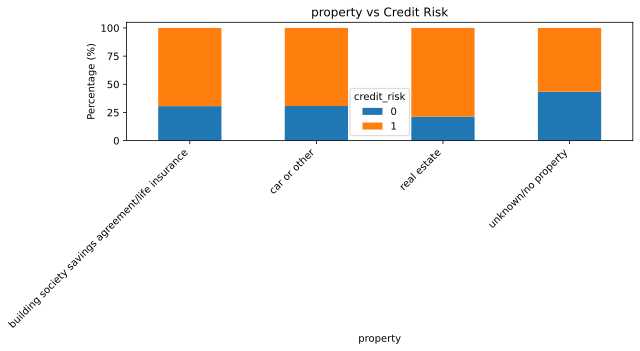

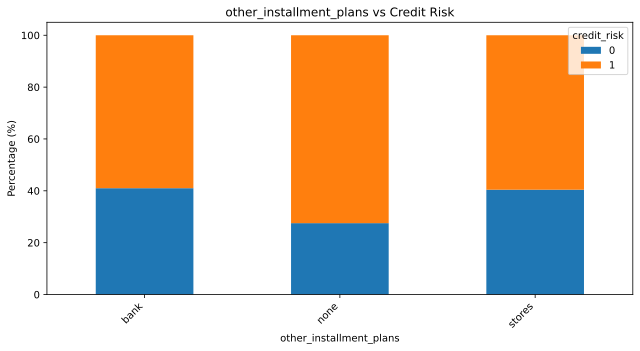

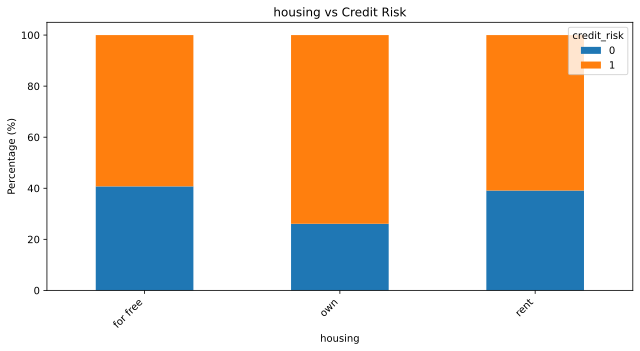

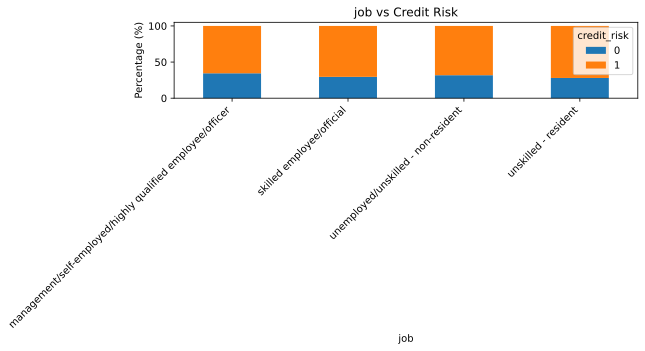

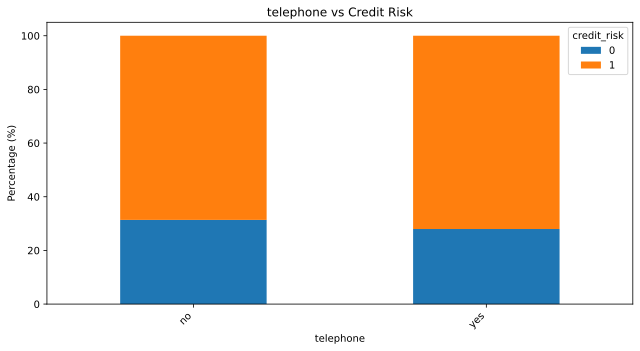

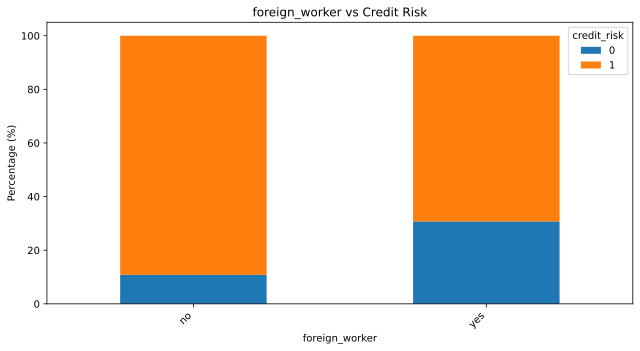

In [64]:
for col in categorical_features:
    table = pd.crosstab(
        df[col],
        df["credit_risk"],
        normalize="index"
    ) * 100

    table.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5)
    )

    plt.title(f"{col} vs Credit Risk")
    plt.xlabel(col)
    plt.ylabel("Percentage (%)")
    plt.legend(title="credit_risk")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

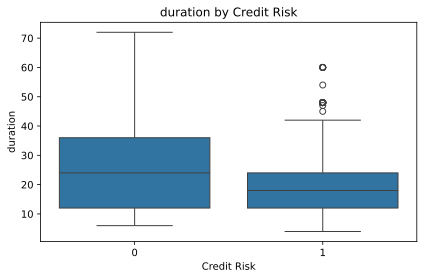

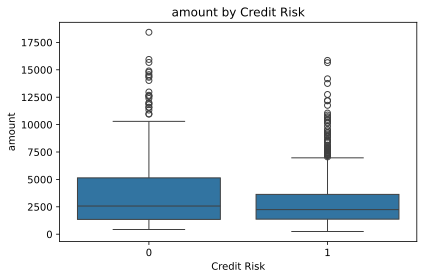

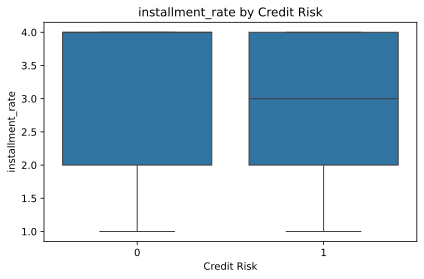

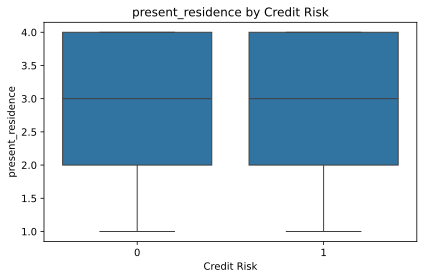

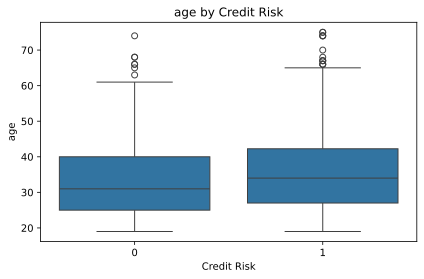

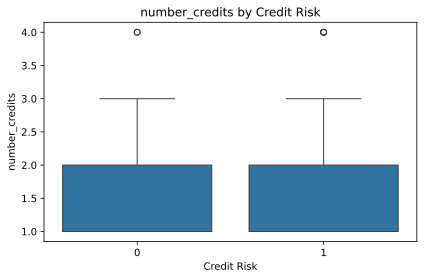

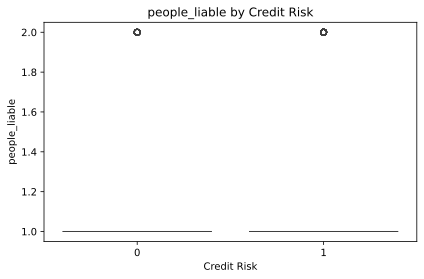

In [65]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=df,
        x="credit_risk",
        y=col
    )

    plt.title(f"{col} by Credit Risk")
    plt.xlabel("Credit Risk")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

# 8. Correlation Analysis

In [66]:
corr_matrix = df[numerical_features].corr()

corr_matrix

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable
duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834
amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142
installment_rate,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207
present_residence,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201
number_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667
people_liable,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000


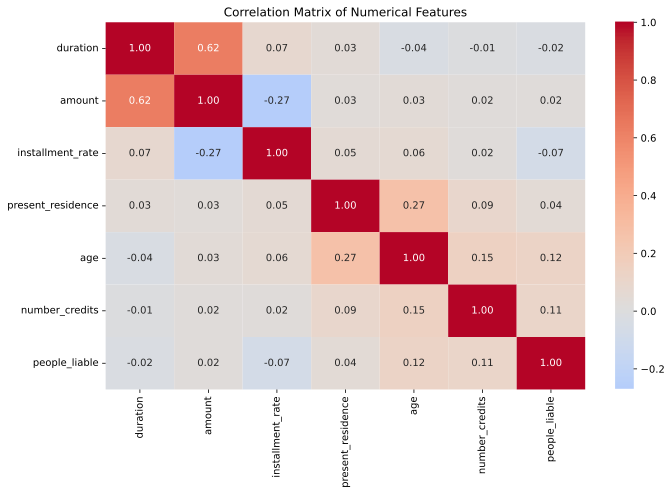

In [67]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [68]:
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > 0.8:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_value
                )
            )

high_corr_pairs

[]

# 9. EDA Summary

- The dataset contains 1000 samples, 20 input features, and 1 binary target.
- No missing values or duplicated rows were found.
- The dataset contains 7 numerical features and 13 categorical features.
- The target variable shows a 70/30 class distribution, indicating moderate class imbalance.
- Several numerical features show skewed distributions and potential outliers, but no values were removed during EDA.
- Categorical features show uneven category distributions, with some rare categories.
- Some features show visibly different distributions across the two target classes.
- No pair of numerical features has |correlation| > 0.8, so no feature is removed based on correlation.
- Further preprocessing and formal feature selection will be performed in the next stage.